#### **Support Vector Machines: Kernel Trick and Eigenfaces**

This notebook has two practical SVM demonstrations:

1. **The Circle of Life**: why a linear SVM fails on concentric circles, and how a radial feature/kernel makes the classes separable.
2. **Facial Recognition with Eigenfaces**: using PCA plus an SVM on the Labeled Faces in the Wild dataset.

The goal is to connect the geometric intuition behind SVMs with a classic real-world high-dimensional classification task.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.datasets import fetch_lfw_people, make_circles
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

#### **The "Circle of Life": Visualizing the Kernel Trick**

A linear SVM tries to separate classes with a straight line in 2D. Concentric circles are a perfect counterexample: no straight line can put the inner circle on one side and the outer ring on the other.

The trick is to represent the data in a richer feature space. For circular data, the distance from the center is the useful hidden feature.

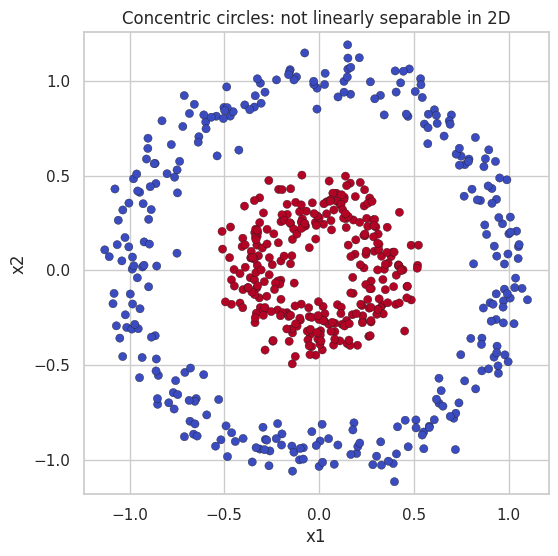

In [2]:
X, y = make_circles(n_samples=600, factor=0.35, noise=0.08, random_state=RANDOM_STATE)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=35, edgecolor="k", linewidth=0.25)
plt.title("Concentric circles: not linearly separable in 2D")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()

#### **The Problem: A Linear SVM Fails**

A linear SVM can only draw a line. On this dataset, any line cuts through both classes.

Linear SVM training accuracy: 0.507


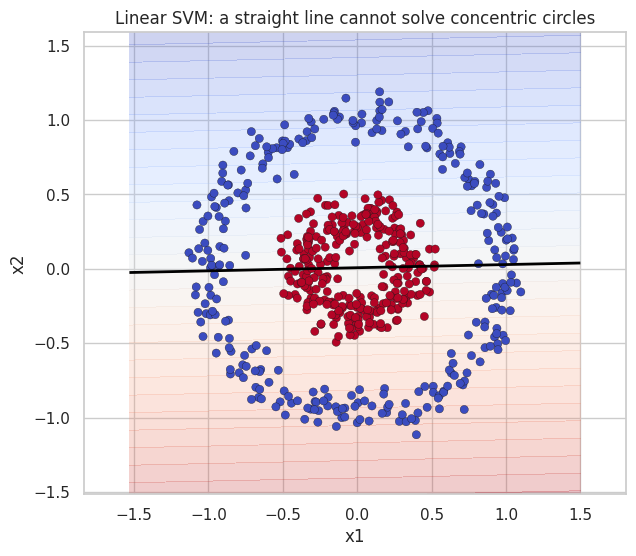

In [3]:
def plot_2d_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
    y_min, y_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, levels=30, cmap="coolwarm", alpha=0.25)
    plt.contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=35, edgecolor="k", linewidth=0.25)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.axis("equal")
    plt.show()


linear_svm = make_pipeline(StandardScaler(), LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=20_000))
linear_svm.fit(X, y)

print(f"Linear SVM training accuracy: {linear_svm.score(X, y):.3f}")
plot_2d_decision_boundary(linear_svm, X, y, "Linear SVM: a straight line cannot solve concentric circles")

#### **The Magic: RBF Kernel SVM**

The RBF kernel compares points by radial similarity. It lets the SVM build a nonlinear boundary in the original 2D space while still solving a linear separation problem in an implicit higher-dimensional feature space.

RBF SVM training accuracy: 1.000


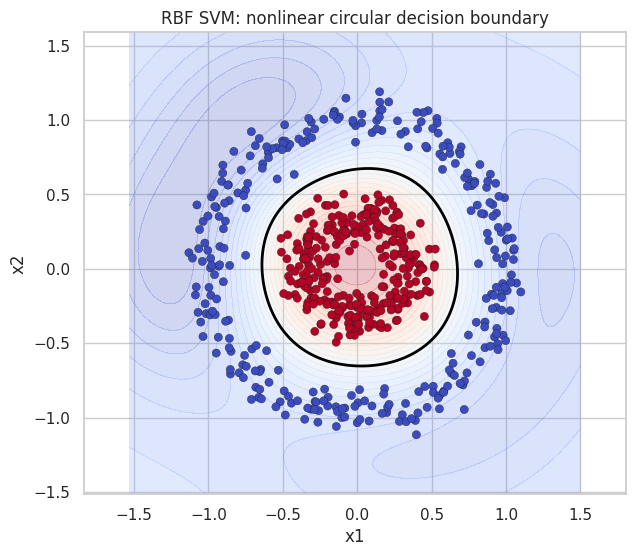

In [4]:
rbf_svm = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma="scale"))
rbf_svm.fit(X, y)

print(f"RBF SVM training accuracy: {rbf_svm.score(X, y):.3f}")
plot_2d_decision_boundary(rbf_svm, X, y, "RBF SVM: nonlinear circular decision boundary")

#### **The Visualization: Lift the Data Into 3D**

For this toy dataset, we can explicitly add a radial feature:

$$z = \sqrt{x_1^2 + x_2^2}$$

The inner class has small radius and the outer class has large radius. In this 3D view, the classes become separable by a horizontal plane.

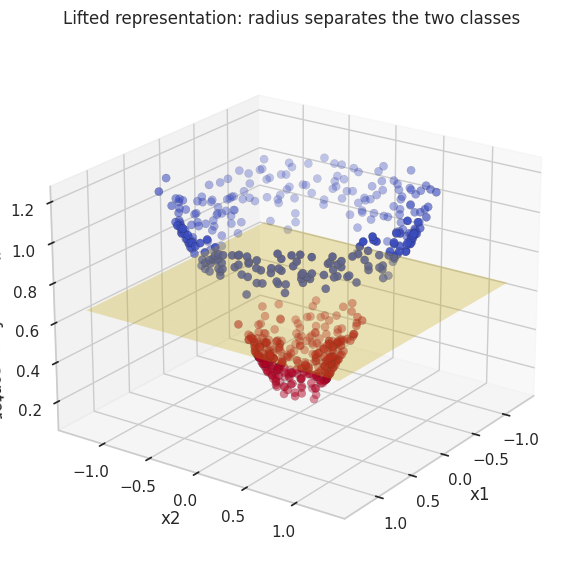

Horizontal separating plane: z = 0.654


In [5]:
radius = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)
class_mean_radius = {label: radius[y == label].mean() for label in np.unique(y)}
inner_label = min(class_mean_radius, key=class_mean_radius.get)
outer_label = max(class_mean_radius, key=class_mean_radius.get)
threshold = 0.5 * (radius[y == inner_label].max() + radius[y == outer_label].min())

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], radius, c=y, cmap="coolwarm", s=35, edgecolor="k", linewidth=0.15)

plane_x, plane_y = np.meshgrid(np.linspace(-1.3, 1.3, 20), np.linspace(-1.3, 1.3, 20))
plane_z = np.full_like(plane_x, threshold)
ax.plot_surface(plane_x, plane_y, plane_z, color="gold", alpha=0.28, linewidth=0)

ax.set_title("Lifted representation: radius separates the two classes")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("z = distance from center")
ax.view_init(elev=22, azim=35)
plt.show()

print(f"Horizontal separating plane: z = {threshold:.3f}")

#### **Key Concept**

The RBF kernel does not literally add only one feature. It corresponds to an implicit, very high-dimensional feature mapping. The 3D radius plot is a simplified visual analogy: data that is inseparable in the original space can become separable after a nonlinear transformation.

#### **2. Facial Recognition: Eigenfaces with SVM**

SVMs were a strong classical method for image classification before deep learning became dominant. Face images are high-dimensional: even small grayscale images can have thousands of pixel features.

The classic pipeline is:

1. Load face images.
2. Use PCA to reduce dimensionality and extract **Eigenfaces**.
3. Train an SVM classifier in the reduced feature space.
4. Evaluate with a classification report and confusion matrix.

Note: `fetch_lfw_people` may download the dataset the first time you run this section.

In [6]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

n_samples, h, w = lfw_people.images.shape
X_faces = lfw_people.data
y_faces = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print(f"Samples: {n_samples}")
print(f"Image shape: {h} x {w} pixels")
print(f"Raw features per image: {X_faces.shape[1]}")
print(f"Classes: {n_classes}")
print(target_names)

Samples: 1288
Image shape: 50 x 37 pixels
Raw features per image: 1850
Classes: 7
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


#### **Preview the Dataset**

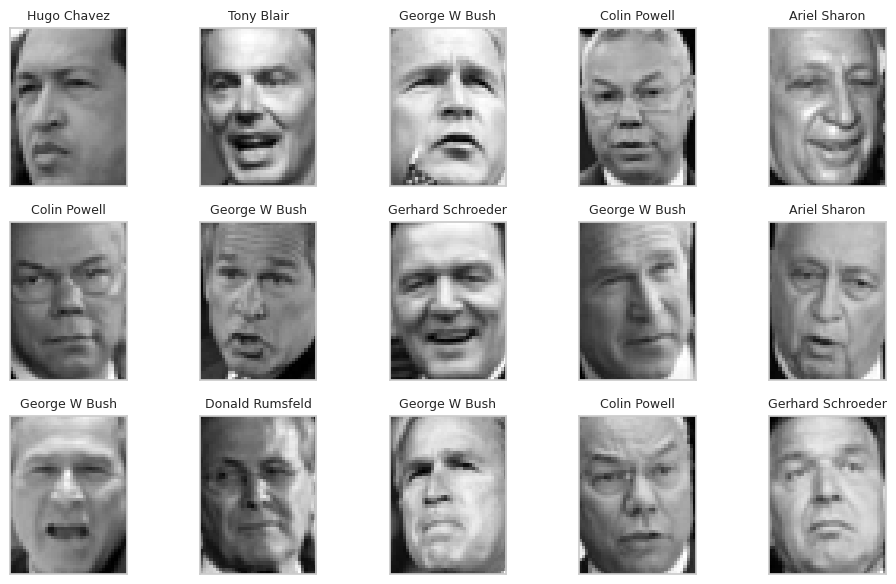

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})
for ax, image, label in zip(axes.ravel(), lfw_people.images[:15], y_faces[:15]):
    ax.imshow(image, cmap="gray")
    ax.set_title(target_names[label], fontsize=9)
plt.tight_layout()
plt.show()

#### **Prepare Data and perform Train/Test Split**

We stratify the split so each person is represented in both training and test sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_faces,
    y_faces,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_faces,
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 966
Test samples: 322


#### **Preprocessing: PCA and Eigenfaces**

PCA learns a smaller set of basis images. These basis images are called **Eigenfaces**. Each face can then be represented by a compact vector of PCA coefficients instead of thousands of raw pixel values.

In [9]:
n_components = 150

pca = PCA(n_components=n_components, svd_solver="randomized", whiten=True, random_state=RANDOM_STATE)
pca.fit(X_train)

eigenfaces = pca.components_.reshape((n_components, h, w))
explained = pca.explained_variance_ratio_.sum()
print(f"Total explained variance with {n_components} components: {explained:.2%}")

Total explained variance with 150 components: 94.61%


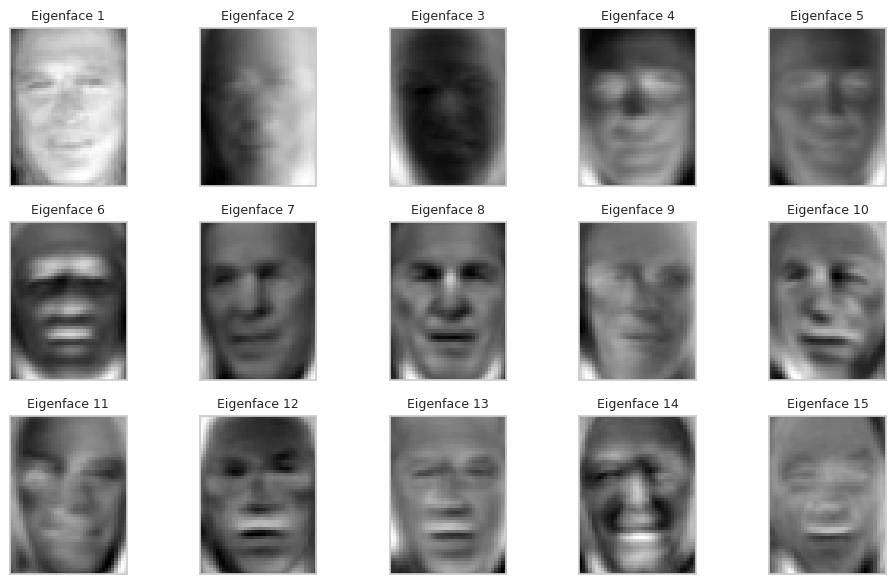

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenfaces[i], cmap="gray")
    ax.set_title(f"Eigenface {i + 1}", fontsize=9)
plt.tight_layout()
plt.show()

#### **Classification: PCA + SVM**

The pipeline below runs PCA first and then trains an SVM classifier. `GridSearchCV` tests a small set of `C` and `gamma` values for the RBF SVM.

In [11]:
pipeline = make_pipeline(
    PCA(n_components=n_components, svd_solver="randomized", whiten=True, random_state=RANDOM_STATE),
    SVC(kernel="rbf", class_weight="balanced"),
)

param_grid = {
    "svc__C": [1, 5, 10, 50],
    "svc__gamma": [0.0001, 0.0005, 0.001, 0.005],
}

grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.3f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'svc__C': 5, 'svc__gamma': 0.005}
Best cross-validation score: 0.836


#### **Analysis: Classification Report**

In [13]:
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.93      0.68      0.79        19
     Colin Powell       0.89      0.92      0.90        59
  Donald Rumsfeld       0.87      0.67      0.75        30
    George W Bush       0.81      0.97      0.88       133
Gerhard Schroeder       0.91      0.74      0.82        27
      Hugo Chavez       1.00      0.61      0.76        18
       Tony Blair       0.97      0.83      0.90        36

         accuracy                           0.86       322
        macro avg       0.91      0.77      0.83       322
     weighted avg       0.87      0.86      0.86       322



#### **Analysis: Confusion Matrix**

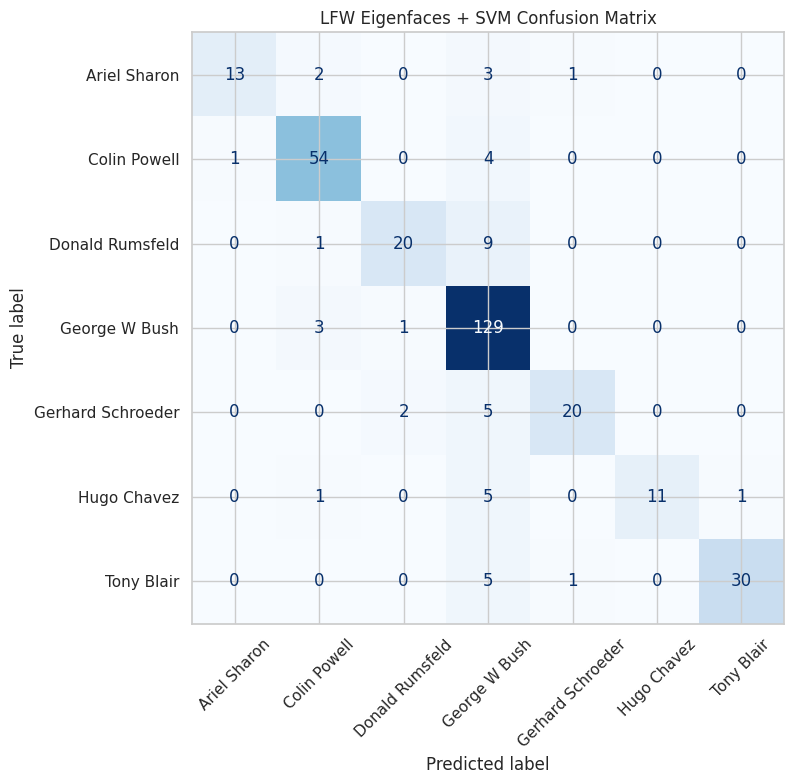

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("LFW Eigenfaces + SVM Confusion Matrix")
plt.tight_layout()
plt.show()

#### **Inspect Predictions**

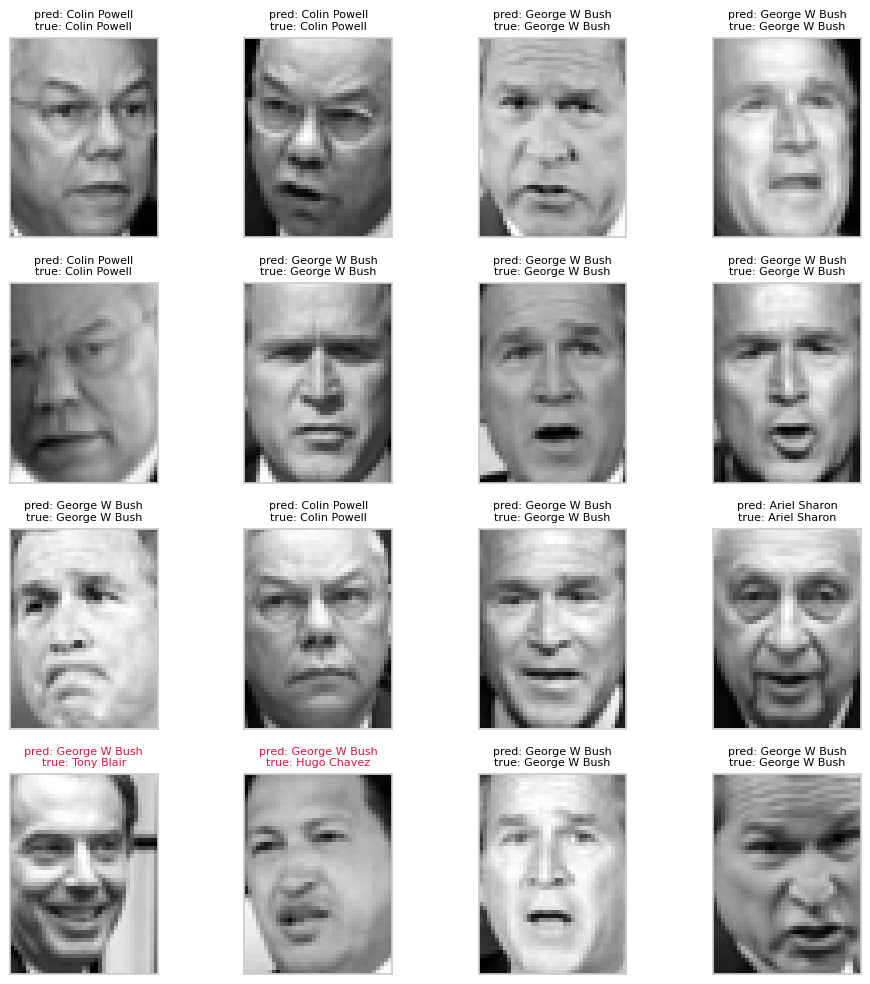

In [15]:
def title_for_prediction(predicted, true):
    color = "black" if predicted == true else "crimson"
    title = f"pred: {target_names[predicted]}\ntrue: {target_names[true]}"
    return title, color


fig, axes = plt.subplots(4, 4, figsize=(10, 10), subplot_kw={"xticks": [], "yticks": []})
for ax, image_vector, predicted, true in zip(axes.ravel(), X_test[:16], y_pred[:16], y_test[:16]):
    ax.imshow(image_vector.reshape(h, w), cmap="gray")
    title, color = title_for_prediction(predicted, true)
    ax.set_title(title, fontsize=8, color=color)
plt.tight_layout()
plt.show()

#### **Learning Point**

SVMs are effective in high-dimensional spaces, especially when paired with a good representation. PCA turns raw pixels into a lower-dimensional face representation, and the SVM learns class boundaries in that compact feature space.

This pipeline is historically important: before deep neural networks became the dominant image-classification approach, Eigenfaces plus SVMs were a standard and surprisingly strong baseline.